# Real-Time Traffic Accident Severity Prediction System

This notebook develops a machine learning model to predict the severity of traffic accidents in real-time based on various environmental, vehicle, and driver-related factors. The process involves:

1.  **Data Loading and Exploration:** Loading the dataset and understanding its structure and initial characteristics.
2.  **Feature Engineering:** Creating new, informative features from the raw data to improve model performance.
3.  **Data Preprocessing:** Handling missing values, encoding categorical variables, and scaling numerical features to prepare the data for modeling.
4.  **Model Training and Evaluation:** Training multiple classification models and evaluating their performance to identify the best one.
5.  **Model Saving:** Saving the trained model, scaler, and encoders for future use.
6.  **Web Application Deployment:** Building a simple Flask web application to demonstrate real-time predictions using the trained model.

The goal is to build a system that can quickly assess potential accident severity, which could be valuable for emergency response and traffic management.

### Install Necessary Libraries
This cell installs the required Python libraries for this project, including `catboost` for gradient boosting, `flask` and `flask-ngrok` for creating a web application with a public URL, `joblib` for saving and loading models, `scikit-learn` for machine learning utilities, and `pyngrok` for creating a tunnel to the Flask app.

In [22]:
pip install catboost


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Import Libraries
This cell imports all the necessary Python libraries that will be used throughout the notebook for data manipulation, visualization, model training, and saving.

In [23]:
import pandas as pd # Import pandas for data manipulation and analysis
import numpy as np # Import numpy for numerical operations
import matplotlib.pyplot as plt # Import matplotlib for creating static visualizations
import seaborn as sns # Import seaborn for creating statistical graphics

# Import modules from scikit-learn for machine learning tasks
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.preprocessing import LabelEncoder, StandardScaler # For encoding categorical features and scaling numerical features
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # For evaluating model performance

# Import various machine learning models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # Ensemble models
from xgboost import XGBClassifier # Extreme Gradient Boosting model
from catboost import CatBoostClassifier # CatBoost model

import joblib # For saving and loading Python objects, including trained models

### Load and Explore the Dataset
This cell loads the accident data from a CSV file into a pandas DataFrame. It then prints the shape of the DataFrame (number of rows and columns), displays the first few rows to show the data structure, and provides information about the columns, including data types and non-null counts.

In [24]:
# Load the dataset from the specified CSV file into a pandas DataFrame
df = pd.read_csv("RTA_Dataset.csv")

# Print the shape of the DataFrame (number of rows, number of columns)
print("Shape:", df.shape)
# Display the first 5 rows of the DataFrame to get a glimpse of the data
print(df.head())
# Print concise information about the DataFrame, including column data types and non-null values
print(df.info())

Shape: (15000, 13)
    Time Day_of_week Weather Vehicle_type  Average_speed Driving_Experience  \
0  22:08   Wednesday   Foggy        Truck         120.89             Novice   
1  06:33   Wednesday   Clear      Bicycle          97.95       Intermediate   
2  01:22    Saturday  Cloudy          Bus         137.44       Intermediate   
3  18:02      Friday   Clear          Bus          47.69        Experienced   
4  12:45    Thursday   Clear      Bicycle          99.43       Intermediate   

  Type_of_Collision     Area Road_Alignment Traffic_Density Road_Condition  \
0        Pedestrian  Highway       Junction            High          Muddy   
1        Pedestrian    Rural       Straight             Low            Wet   
2  Vehicle overturn    Urban       Straight             Low            Dry   
3          Rear-end  Highway       Junction             Low          Muddy   
4              Side    Urban       Straight             Low            Dry   

   Temperature (°C) Accident_severity

###  Heatmap
This cell calculates and visualizes the correlation matrix for the numerical features in the dataset using a heatmap. A heatmap helps to understand the relationships between different numerical variables.

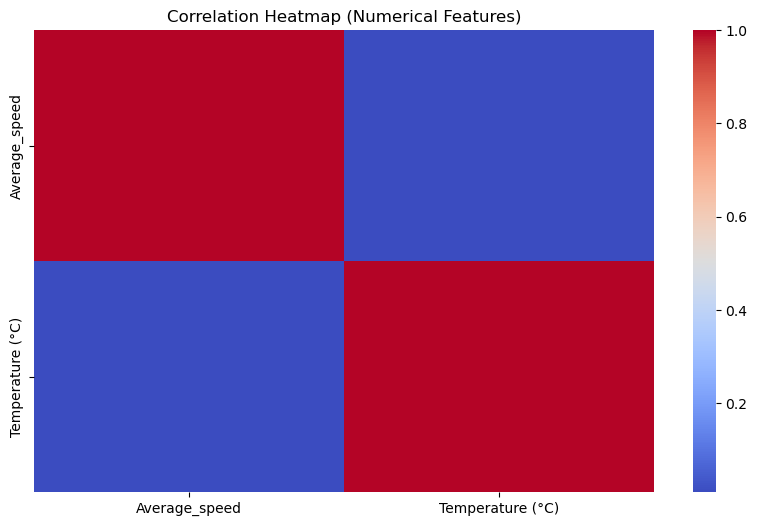

In [25]:
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10,6)) # Set the size of the figure
sns.heatmap(numerical_df.corr(), annot=False, cmap="coolwarm") # Generate the heatmap
plt.title("Correlation Heatmap (Numerical Features)") # Set the title of the heatmap
plt.show() # Display the plot

### Feature Engineering
This cell creates new features from existing ones to improve the model's performance. It extracts the hour from the 'Time' column, creates a 'Day_or_Night' feature, adds an 'Is_Weekend' indicator, and categorizes 'Average_speed' into different bins.

In [26]:
# Convert time to hour feature
# Use errors='coerce' to handle potential parsing issues, fillna(0) and astype(int) for robustness
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour.fillna(0).astype(int)


# Create new feature: Day_or_Night based on hour
df['Day_or_Night'] = np.where((df['Hour'] >= 6) & (df['Hour'] <= 18), "Day", "Night")

# Create Weekend Feature: 1 if Saturday or Sunday, 0 otherwise
df['Is_Weekend'] = df['Day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Speed Category Binning (Ensure bins and labels match the Flask app)
# Categorize 'Average_speed' into 'Low', 'Moderate', and 'High' bins
df['Speed_Category'] = pd.cut(df['Average_speed'], bins=[0,40,80,120], labels=['Low','Moderate','High'], include_lowest=True)

# Print confirmation message
print("\nFeature Engineering Complete")
# Print the names of the new columns added
print("New Columns Added:",
      [col for col in ['Hour', 'Day_or_Night', 'Is_Weekend', 'Speed_Category']
       if col in df.columns])
# Print the list of all columns in the DataFrame after feature engineering
print("\nDataFrame columns after feature engineering:", df.columns.tolist())


Feature Engineering Complete
New Columns Added: ['Hour', 'Day_or_Night', 'Is_Weekend', 'Speed_Category']

DataFrame columns after feature engineering: ['Time', 'Day_of_week', 'Weather', 'Vehicle_type', 'Average_speed', 'Driving_Experience', 'Type_of_Collision', 'Area', 'Road_Alignment', 'Traffic_Density', 'Road_Condition', 'Temperature (°C)', 'Accident_severity', 'Hour', 'Day_or_Night', 'Is_Weekend', 'Speed_Category']


### Check Target Distribution
This cell examines the distribution of the target variable, 'Accident_severity', by counting the occurrences of each severity level. This is important for understanding the class balance in the dataset.

In [27]:
target = "Accident_severity"
# Print the distribution of the target variable
print(df[target].value_counts())

Accident_severity
Fatal Injury      5000
Serious Injury    5000
Slight Injury     5000
Name: count, dtype: int64


### Handle Missing Values
This cell removes rows with any missing values from the DataFrame. This is a simple way to handle missing data, ensuring that the model doesn't encounter issues with incomplete information.

In [28]:
# Remove rows with any missing values from the DataFrame
df = df.dropna()

### Identify Categorical and Numerical Columns
This cell separates the DataFrame columns into two lists: one for categorical columns (object and category data types) and one for numerical columns (integer and float data types). This separation is useful for applying different preprocessing steps to each type of column.

In [29]:
# Select columns with 'object' or 'category' data types as categorical columns
cat_cols = df.select_dtypes(include='object').columns
# Select columns with 'int64' or 'float64' data types as numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Print the identified categorical and numerical column names
print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: Index(['Time', 'Day_of_week', 'Weather', 'Vehicle_type', 'Driving_Experience',
       'Type_of_Collision', 'Area', 'Road_Alignment', 'Traffic_Density',
       'Road_Condition', 'Accident_severity', 'Day_or_Night'],
      dtype='object')
Numerical: Index(['Average_speed', 'Temperature (°C)', 'Hour', 'Is_Weekend'], dtype='object')


### Encode Categorical Features
This cell converts the categorical features into numerical representations using Label Encoding. This is a necessary step as most machine learning algorithms require numerical input. The encoders are saved for later use in the prediction app.

In [30]:
# Encode categorical columns
label_encoders = {} # Dictionary to store fitted encoders
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder() # Initialize LabelEncoder for each column
    df[col] = le.fit_transform(df[col]) # Fit and transform the column
    label_encoders[col] = le # Store the fitted encoder

# Save encoders for later use in the app
joblib.dump(label_encoders, "encoders.pkl")

['encoders.pkl']

### Scale Numerical Features
This cell scales the numerical features using StandardScaler. Scaling helps to standardize the range of numerical features, which can improve the performance of some machine learning algorithms. The scaler is saved for later use in the prediction app.

In [31]:
# Separate features (X) and target (y)
X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

# Initialize and fit the StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Save the fitted scaler for later use
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

### Split Data into Training and Testing Sets
This cell splits the preprocessed data into training and testing sets. The training set is used to train the machine learning models, and the testing set is used to evaluate their performance on unseen data.

In [32]:
# Split the scaled data and target variable into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Train and Evaluate Multiple Models
This cell trains several different machine learning models, including RandomForest, XGBoost, CatBoost, and GradientBoosting, on the training data. It then evaluates the performance of each model on the testing data using accuracy as a metric and prints the results.

Training RandomForest...
RandomForest Accuracy: 0.9478
Training XGBoost...
XGBoost Accuracy: 0.9410
Training CatBoost...
CatBoost Accuracy: 0.9380
Training GradientBoosting...
GradientBoosting Accuracy: 0.8284

Model Accuracy Results:
{'RandomForest': 0.9478032294404807, 'XGBoost': 0.9410439354111904, 'CatBoost': 0.9380398047315058, 'GradientBoosting': 0.8283890349230192}


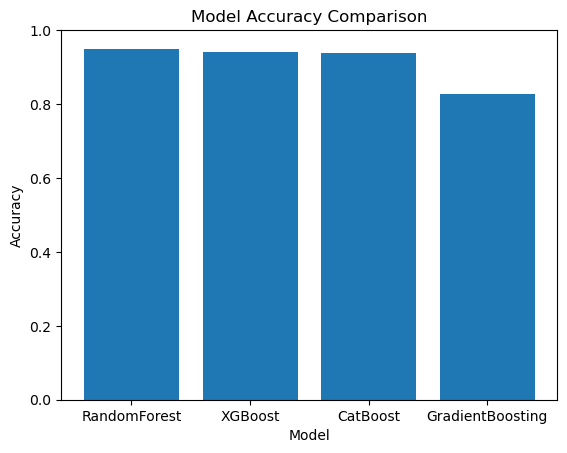

In [33]:
# Define the models to be trained
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0), # verbose=0 to suppress training output
    "GradientBoosting": GradientBoostingClassifier()
}

results = {} # Dictionary to store accuracy results for each model

# Iterate through each model, train, predict, and evaluate
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train) # Train the model
    y_pred = model.predict(X_test) # Make predictions on the test set
    results[name] = accuracy_score(y_test, y_pred) # Calculate and store accuracy
    print(f"{name} Accuracy: {results[name]:.4f}")

# Print the accuracy results for all models
print("\nModel Accuracy Results:")
print(results)
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


### Select and Evaluate the Best Model
This cell identifies the model with the highest accuracy from the trained models. It then prints a detailed classification report and displays a confusion matrix for the best model, providing a comprehensive evaluation of its performance.

Best Model: RandomForest
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       654
           1       0.92      0.95      0.93      1041
           2       0.97      0.95      0.96       968

    accuracy                           0.95      2663
   macro avg       0.95      0.95      0.95      2663
weighted avg       0.95      0.95      0.95      2663



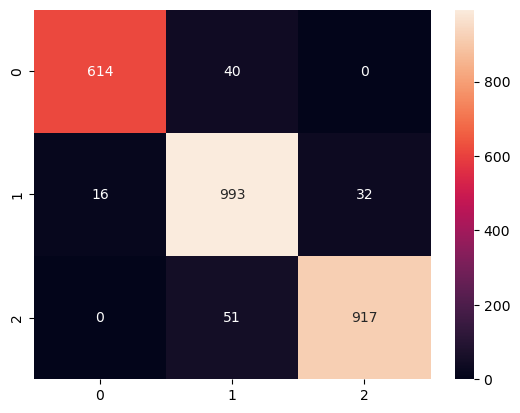

In [34]:
# Identify the name of the model with the highest accuracy from the results dictionary
best_model_name = max(results, key=results.get)
# Get the best performing model object from the models dictionary
best_model = models[best_model_name]

# Print the name of the best model
print("Best Model:", best_model_name)

# Make predictions on the test set using the best model
y_pred = best_model.predict(X_test)

# Print the classification report to evaluate the model's performance
# The report includes precision, recall, f1-score, and support for each class
print(classification_report(y_test, y_pred))

# Generate and display a confusion matrix as a heatmap
# A confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d') # annot=True displays the numbers, fmt='d' formats them as integers
plt.show() # Display the plot

### Visualize Feature Importances
This cell visualizes the importance of different features for the trained models (if the model supports feature importance). This helps in understanding which features contribute most to the model's predictions.

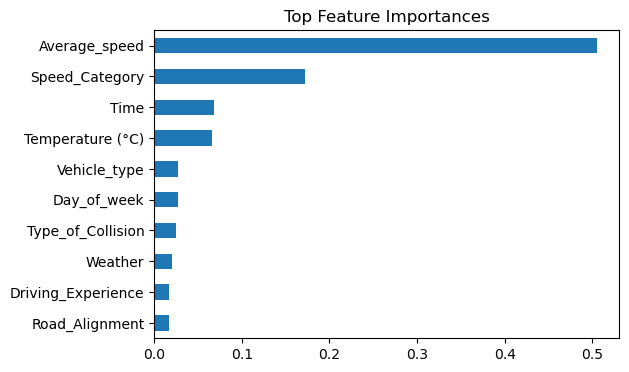

In [35]:
# Check if the best model has a 'feature_importances_' attribute (common in tree-based models)
if hasattr(best_model, "feature_importances_"):
    # Create a pandas Series from feature importances with feature names as index
    importances = pd.Series(best_model.feature_importances_, index=X.columns)

    # Sort feature importances and select the top 10, then plot as a horizontal bar chart
    importances.sort_values().tail(10).plot(kind='barh', figsize=(6,4))
    plt.title("Top Feature Importances") # Set the title of the plot
    plt.show() # Display the plot

###  Save the Best Model
This cell saves the best-performing trained model to a file using `joblib`. This allows the trained model to be loaded later for making predictions without needing to retrain it.

In [36]:
# Save the best-performing trained model to a file
joblib.dump(best_model, f"best_model_{best_model_name}.pkl")
# Print a confirmation message
print("Model Saved Successfully!")

Model Saved Successfully!


### Install Dependencies for Flask App
This cell installs the necessary Python libraries to build and run a web application using Flask and expose it to the internet using ngrok.

In [37]:
# Install dependencies
import sys
!{sys.executable} -m pip install flask flask-ngrok joblib scikit-learn pyngrok --no-warn-script-location


Defaulting to user installation because normal site-packages is not writeable


### Create Templates Folder
This cell creates a folder named `templates`. This folder will be used to store HTML files for the Flask web application.

In [17]:
!mkdir template
import os
os.makedirs("template", exist_ok=True)
print("✅ Folder 'templates_frontend' created (or already exists).")


✅ Folder 'templates_frontend' created (or already exists).


A subdirectory or file template already exists.


### Create HTML Template for the Web App
This cell writes the HTML code for the web application's user interface into a file named `index.html` inside the `templates` folder. This HTML file contains a form for user input and a section to display the prediction result.

In [44]:
%%writefile templates/index.html
<!DOCTYPE html>
<html>
<head>
  <meta charset="utf-8">
  <title>Accident Severity Prediction</title>
  <style>
    body { font-family: Arial, sans-serif; margin: 30px; background:#f9fbfd; }
    form { max-width:700px; margin:auto; background:#ffffff; padding:20px; border-radius:8px; box-shadow:0 2px 6px rgba(0,0,0,0.08);}
    label { display:block; margin-top:10px; font-weight:600; }
    input, select { width:100%; padding:8px; margin-top:6px; border-radius:6px; border:1px solid #ccc; }
    button { margin-top:14px; padding:12px; width:100%; background:#007bff; color:white; border:none; border-radius:6px; font-size:16px; cursor:pointer; }
    .result { text-align:center; margin-top:18px; font-size:18px; font-weight:600; }
  </style>
</head>
<body>
  <h2 style="text-align:center">🚗 Accident Severity Prediction</h2>

  <form method="post" action="/predict">
    <label>Time (HH:MM)</label>
    <input name="Time" type="time" value="{{ data.get('Time','14:30') if data else '14:30' }}">

    <label>Day of Week</label>
    <select name="Day_of_week">
      {% for day in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'] %}
        <option value="{{ day }}" {% if data and data.get('Day_of_week')==day %}selected{% endif %}>{{ day }}</option>
      {% endfor %}
    </select>

    <label>Weather</label>
    <select name="Weather">
      {% for w in ['Clear','Rainy','Fog','Cloudy','Windy'] %}
        <option value="{{ w }}" {% if data and data.get('Weather')==w %}selected{% endif %}>{{ w }}</option>
      {% endfor %}
    </select>

    <label>Vehicle Type</label>
    <select name="Vehicle_type">
      {% for v in ['Car','Motorcycle','Bus','Truck','Bicycle','Auto'] %}
        <option value="{{ v }}" {% if data and data.get('Vehicle_type')==v %}selected{% endif %}>{{ v }}</option>
      {% endfor %}
    </select>

    <label>Average Speed (km/h)</label>
    <input name="Average_speed" type="number" value="{{ data.get('Average_speed',50) if data else 50 }}">

    <label>Driving Experience</label>
    <select name="Driving_Experience">
      {% for d in ['Novice','Intermediate','Experienced'] %}
        <option value="{{ d }}" {% if data and data.get('Driving_Experience')==d %}selected{% endif %}>{{ d }}</option>
      {% endfor %}
    </select>

    <label>Type of Collision</label>
    <select name="Type_of_Collision">
      {% for c in ['Head-on','Rear-end','Side','Vehicle overturn','Pedestrian'] %}
        <option value="{{ c }}" {% if data and data.get('Type_of_Collision')==c %}selected{% endif %}>{{ c }}</option>
      {% endfor %}
    </select>

    <label>Area</label>
    <select name="Area">
      {% for a in ['Urban','Rural','Highway'] %}
        <option value="{{ a }}" {% if data and data.get('Area')==a %}selected{% endif %}>{{ a }}</option>
      {% endfor %}
    </select>

    <label>Road Alignment</label>
    <select name="Road_Alignment">
      {% for r in ['Straight','Curve','Junction'] %}
        <option value="{{ r }}" {% if data and data.get('Road_Alignment')==r %}selected{% endif %}>{{ r }}</option>
      {% endfor %}
    </select>

    <label>Traffic Density</label>
    <select name="Traffic_Density">
      {% for t in ['Low','Medium','High'] %}
        <option value="{{ t }}" {% if data and data.get('Traffic_Density')==t %}selected{% endif %}>{{ t }}</option>
      {% endfor %}
    </select>

    <label>Road Condition</label>
    <select name="Road_Condition">
      {% for rc in ['Dry','Wet','Muddy'] %}
        <option value="{{ rc }}" {% if data and data.get('Road_Condition')==rc %}selected{% endif %}>{{ rc }}</option>
      {% endfor %}
    </select>

    <label>Temperature (°C)</label>
    <input type="number" name="Temperature (°C)" value="{{ data.get('Temperature (°C)',25) if data else 25 }}" step="0.1" required>

    <button type="submit">Predict</button>
  </form>

  {% if prediction %}
    <div class="result">{{ prediction }}</div>
  {% endif %}
</body>
</html>


Overwriting templates/index.html


### Run the Flask Web Application with Ngrok
This cell contains the Python code for the Flask web application. It loads the trained model, scaler, and encoders, defines routes for the home page and prediction, processes user input, makes predictions using the loaded model, and serves the results via a web interface exposed through a public URL.

In [45]:
# Real-Time Accident Severity Prediction System

# Import necessary libraries for Flask app
from flask import Flask, request, render_template
import pandas as pd
import numpy as np
import joblib
from datetime import datetime

# Flask Setup
app = Flask(__name__, template_folder="templates")

# Load Model, Scaler, and Encoders
# Define file paths for saved model, scaler, and encoders
MODEL_FILE = "best_model_RandomForest.pkl"
SCALER_FILE = "scaler.pkl"
ENCODER_FILE = "encoders.pkl"

# Load pre-trained objects
model = joblib.load(MODEL_FILE)
scaler = joblib.load(SCALER_FILE)
encoders = joblib.load(ENCODER_FILE)


# Routes


# Define the route for the home page
@app.route('/')
def home():
    return render_template("index.html")

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Convert all form data to dictionary (makes Jinja easier to use)
        data = request.form.to_dict()

        # Convert numeric fields safely
        data["Average_speed"] = float(data["Average_speed"])
        data["Temperature (°C)"] = float(data["Temperature (°C)"])

        df = pd.DataFrame([data])

        # Feature Engineering
        df["Hour"] = pd.to_datetime(df["Time"], errors='coerce').dt.hour.fillna(0).astype(int)
        df["Day_or_Night"] = np.where((df["Hour"] >= 6) & (df["Hour"] <= 18), "Day", "Night")
        df["Is_Weekend"] = df["Day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
        df["Speed_Category"] = pd.cut(
            df["Average_speed"], bins=[0, 40, 80, 120],
            labels=["Low", "Moderate", "High"], include_lowest=True
        )

        df_input = df.copy()

        # Apply encoders to categorical columns
        for col, encoder in encoders.items():
            if col in df_input.columns:
                try:
                    df_input[col] = encoder.transform(df_input[col])
                except ValueError:
                    df_input[col] = encoder.transform([encoder.classes_[0]])

        # Match feature order
        feature_order = [
            'Time', 'Day_of_week', 'Weather', 'Vehicle_type',
            'Average_speed', 'Driving_Experience', 'Type_of_Collision', 'Area',
            'Road_Alignment', 'Traffic_Density', 'Road_Condition', 'Temperature (°C)',
            'Hour', 'Day_or_Night', 'Is_Weekend', 'Speed_Category'
        ]
        df_input = df_input.reindex(columns=feature_order, fill_value=0)
        df_input = df_input.apply(pd.to_numeric, errors='coerce').fillna(0)

        # Scale and predict
        df_scaled = scaler.transform(df_input)
        pred = model.predict(df_scaled)[0]

        # Decode prediction manually
        severity_mapping = {0: "Fatal Injury", 1: "Serious Injury", 2: "Slight Injury"}
        label = severity_mapping.get(int(pred), "Unknown")

        # Emoji output
        if label == "Fatal Injury":
            result = "🚨 Fatal Injury"
        elif label == "Serious Injury":
            result = "⚠️ Serious Injury"
        else:
            result = "✅ Slight Injury"

        
        return render_template("index.html", prediction=result, data=data)

    except Exception as e:
        return render_template("index.html", prediction=f"❌ Error: {e}", data=request.form.to_dict())


# Run Flask app locally

if __name__ == "__main__":
    print("🚀 Flask app running at: http://127.0.0.1:5000/")
    app.run(port=5000, debug=False, use_reloader=False)



🚀 Flask app running at: http://127.0.0.1:5000/
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [11/Nov/2025 16:37:53] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [11/Nov/2025 16:37:59] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [11/Nov/2025 16:41:01] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [11/Nov/2025 16:42:39] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [11/Nov/2025 16:43:04] "POST /predict HTTP/1.1" 200 -
